In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
events_df = pd.read_csv(
    'ABCD/sub-ABCD1_ses-baselineYear1Arm1_task-MID_run-01_events.csv')
events_df.head()

,Subject,Handedness,Run,SubTrial,Condition,Cue.OnsetTime,Cue.Duration,Anticipation.Duration,Anticipation.OnsetTime,Probe.Duration,...,Result,prbacc,prbrt,OverallRT,meanrt,moneyamt,ResponseCheck,Feedback.OnsetTime,FeedbackDuration,SessionDate
0,0191C80U,Right,1,1.0,LgPun,0.022,2.0,1.5,1.995,0.339,...,You lose $5!,0.0,0.0,NaN,?,-5.0,You pressed too slow!,3.902,1.611,04-08-2018
1,0191C80U,Right,1,2.0,SmallReward,5.524,2.0,3.5,7.498,0.339,...,You did not earn $0.20!,0.0,0.0,354.0,?,-5.0,You pressed too slow!,11.428,1.611,04-08-2018
2,0191C80U,Right,1,3.0,LgPun,13.034,2.0,3.0,15.008,0.339,...,You keep $5!,1.0,320.0,320.0,320,-5.0,Correct Response!,18.436,1.611,04-08-2018
3,0191C80U,Right,1,4.0,Triangle,20.042,2.0,1.5,22.015,0.379,...,No money at stake!,1.0,152.0,152.0,320,-5.0,Correct Response!,23.972,1.571,04-08-2018
4,0191C80U,Right,1,5.0,Triangle,25.544,2.0,3.5,27.518,0.379,...,No money at stake!,1.0,248.0,248.0,320,-5.0,Correct Response!,31.482,1.571,04-08-2018


In [3]:
resolution = 0.1
maxtime = np.ceil(events_df['Feedback.OnsetTime'].values[-1] + \
    events_df['FeedbackDuration'].values[-1])

timepoints = np.arange(0, maxtime, resolution)



In [4]:
events_df.columns

Index(['Subject', 'Handedness', 'Run', 'SubTrial', 'Condition',
       'Cue.OnsetTime', 'Cue.Duration', 'Anticipation.Duration',
       'Anticipation.OnsetTime', 'Probe.Duration', 'Probe.OnsetTime',
       'Probe.RESP', 'Result', 'prbacc', 'prbrt', 'OverallRT', 'meanrt',
       'moneyamt', 'ResponseCheck', 'Feedback.OnsetTime', 'FeedbackDuration',
       'SessionDate'],
      dtype='object')

In [5]:
def get_trial_regressors(df, resolution=.1, padding=2):
    maxtime = np.round(df.iloc[-1, df.columns=='Feedback.OnsetTime'][0] + 
                       df.iloc[-1, df.columns=='FeedbackDuration'][0] + padding).astype('int')
    
    sf = pd.DataFrame({'time': np.arange(0, maxtime + resolution, resolution)})
    for var in ['cue', 'fix', 'probe', 'fb']:
        sf[var] = 0
    
    all_event_times = []
    for trialnum in df.index:
        trial_df = df.iloc[trialnum, :]
        
        cue_offset = trial_df['Cue.Duration'] + trial_df['Cue.OnsetTime']
        fix_onset = trial_df['Anticipation.OnsetTime']
        fix_offset = fix_onset  + trial_df['Anticipation.Duration']
        probe_onset = trial_df['Probe.OnsetTime']
        probe_offset = probe_onset + trial_df['Probe.Duration']
        fb_onset = trial_df['Feedback.OnsetTime']
        fb_offset = fb_onset + trial_df['FeedbackDuration']
        
        event_times = pd.Series({
            'cue_onset': trial_df['Cue.OnsetTime'],
            'cue_offset': cue_offset,
            'fix_onset': fix_onset,
            'fix_offset': fix_offset,
            'probe_onset': probe_onset,
            'probe_offset': probe_offset,
            'fb_onset': fb_onset,
            'fb_offset': fb_offset})
        all_event_times.append(event_times)
        
        cue_idx = np.logical_and(sf.time.values >= event_times.cue_onset, sf.time.values <= event_times.cue_offset)
        sf.loc[cue_idx == True, 'cue'] = 1
        fix_idx = np.logical_and(sf.time.values >= event_times.fix_onset, sf.time.values <= event_times.fix_offset)
        sf.loc[fix_idx, 'fix'] = 1
        probe_idx = np.logical_and(sf.time.values >= event_times.probe_onset, sf.time.values <= event_times.probe_offset)
        sf.loc[probe_idx, 'probe'] = 1
        fb_idx = np.logical_and(sf.time.values >= event_times.fb_onset, sf.time.values <= event_times.fb_offset)
        sf.loc[fb_idx, 'fb'] = 1
    return(sf, all_event_times)

sf, all_event_times = get_trial_regressors(events_df, resolution)
sf.set_index('time', inplace=True)

/var/folders/r2/f85nyfr1785fj4257wkdj7480000gn/T/ipykernel_79498/3173360131.py:2: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  maxtime = np.round(df.iloc[-1, df.columns=='Feedback.OnsetTime'][0] +
/var/folders/r2/f85nyfr1785fj4257wkdj7480000gn/T/ipykernel_79498/3173360131.py:3: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  df.iloc[-1, df.columns=='FeedbackDuration'][0] + padding).astype('int')


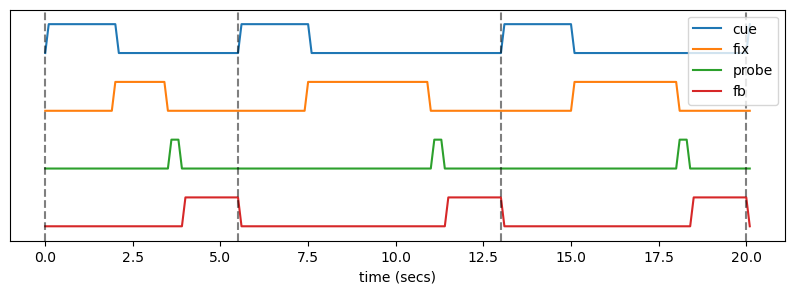

In [38]:
cutoff = 20.2
figsize = (10, 3.)
sf_plot = sf.copy()
sf_plot['cue'] = sf_plot['cue'] + 6
sf_plot['fix'] = sf_plot['fix'] + 4
sf_plot['probe'] = sf_plot['probe'] + 2
plt.figure(figsize=figsize)
plt.plot(sf_plot[:cutoff])
plt.legend(sf_plot.columns)
plt.xlabel('time (secs)')
plt.ylim(-0.5, 7.5)
plt.yticks([])  # This line turns off the y-axis labels

cue_onsets = np.where(np.diff(sf_plot['cue'].values) >= 1)[0][:4]
for ons in cue_onsets:
    plt.axvline(sf_plot.index[ons], color='k', linestyle='--', alpha=0.5)
plt.savefig('abcd_trial_regressors.png', dpi=300)

In [37]:
np.diff(sf_plot['cue'].values)

array([1, 0, 0, ..., 0, 0, 0])

(-0.5, 7.5)

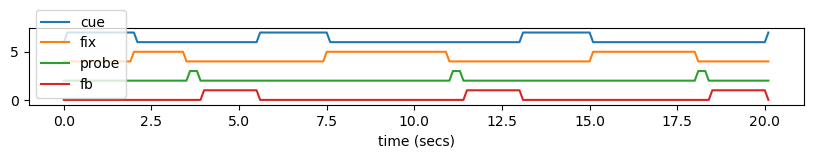

In [7]:
cutoff = 20.2
figsize = (10, 1.)
sf_plot = sf.copy()
sf_plot['cue'] = sf_plot['cue'] + 6
sf_plot['fix'] = sf_plot['fix'] + 4
sf_plot['probe'] = sf_plot['probe'] + 2
plt.figure(figsize=figsize)
plt.plot(sf_plot[:cutoff])
plt.legend(sf_plot.columns)
plt.xlabel('time (secs)')
plt.ylim(-0.5, 7.5)

(-0.5, 3.5)

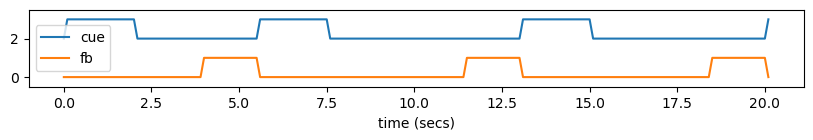

In [8]:
# create example model figures
plt.figure(figsize=figsize)
sf_plot = sf.copy()
del sf_plot['probe']
del sf_plot['fix']
sf_plot['cue'] = sf_plot['cue'] + 2
plt.plot(sf_plot[:cutoff])
plt.legend(sf_plot.columns)
plt.xlabel('time (secs)')
plt.ylim(-.5, 3.5)


(-0.5, 3.5)

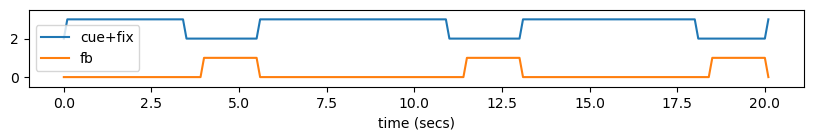

In [9]:
plt.figure(figsize=figsize)
sf_plot = sf.copy()
sf_plot['cue+fix'] = np.clip(sf_plot['cue'] + sf_plot['fix'], 0, 1) + 2
del sf_plot['probe']
del sf_plot['fix']
del sf_plot['cue']
sf_plot = sf_plot[['cue+fix', 'fb']]
plt.plot(sf_plot[:cutoff])
plt.legend(sf_plot.columns)
plt.xlabel('time (secs)')
plt.ylim(-.5, 3.5)


(-0.5, 3.5)

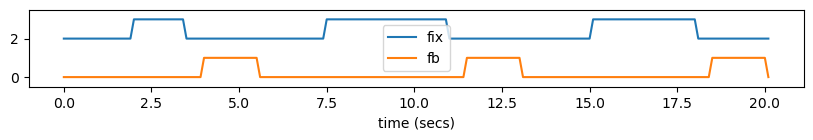

In [10]:
plt.figure(figsize=figsize)
sf_plot = sf.copy()
del sf_plot['probe']
del sf_plot['cue']
sf_plot['fix'] = sf_plot['fix'] + 2
plt.plot(sf_plot[:cutoff])
plt.legend(sf_plot.columns)
plt.xlabel('time (secs)')
plt.ylim(-.5, 3.5)


/var/folders/r2/f85nyfr1785fj4257wkdj7480000gn/T/ipykernel_79498/3173360131.py:2: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  maxtime = np.round(df.iloc[-1, df.columns=='Feedback.OnsetTime'][0] +
/var/folders/r2/f85nyfr1785fj4257wkdj7480000gn/T/ipykernel_79498/3173360131.py:3: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  df.iloc[-1, df.columns=='FeedbackDuration'][0] + padding).astype('int')
/var/folders/r2/f85nyfr1785fj4257wkdj7480000gn/T/ipykernel_79498/332861701.py:24: FutureWarning: The behavior of obj[i:j] with a float-dtype index is deprecated. In a future version, this will be treated as positional instead 

(-0.5, 7.5)

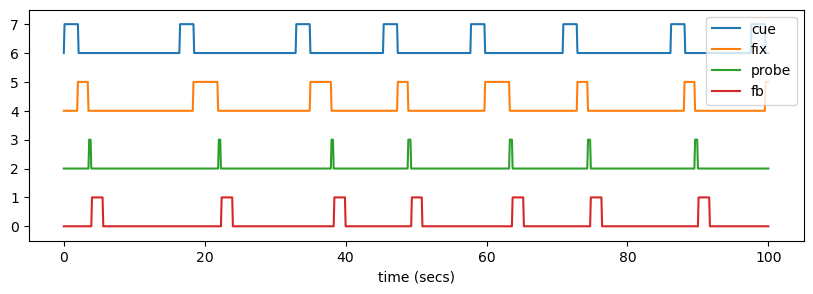

In [11]:
def insert_jitter(events, miun_iti=4, max_iti=12):
    jitter = np.round(np.random.uniform(miun_iti, max_iti, events.shape[0]), 2)
    jitter[0] = 0
    cumulative_jitter = np.cumsum(jitter)
    events['jitter'] = jitter
    events['cumulative_jitter'] = cumulative_jitter
    onset_cols = [col for col in events.columns if 'Onset' in col]
    for col in onset_cols:
        events[col] += cumulative_jitter
    return events

events_jittered = insert_jitter(events_df)
sf_jittered, _ = get_trial_regressors(events_jittered, resolution)

cutoff = 100
figsize = (10, 3.)
sf_plot = sf_jittered.copy()
sf_plot.set_index('time', inplace=True)

sf_plot['cue'] = sf_plot['cue'] + 6
sf_plot['fix'] = sf_plot['fix'] + 4
sf_plot['probe'] = sf_plot['probe'] + 2
plt.figure(figsize=figsize)
plt.plot(sf_plot[:cutoff])
plt.legend(sf_plot.columns)
plt.xlabel('time (secs)')
plt.ylim(-0.5, 7.5)

In [12]:
events_jittered.head()

,Subject,Handedness,Run,SubTrial,Condition,Cue.OnsetTime,Cue.Duration,Anticipation.Duration,Anticipation.OnsetTime,Probe.Duration,...,prbrt,OverallRT,meanrt,moneyamt,ResponseCheck,Feedback.OnsetTime,FeedbackDuration,SessionDate,jitter,cumulative_jitter
0,0191C80U,Right,1,1.0,LgPun,0.022,2.0,1.5,1.995,0.339,...,0.0,NaN,?,-5.0,You pressed too slow!,3.902,1.611,04-08-2018,0.00,0.00
1,0191C80U,Right,1,2.0,SmallReward,16.424,2.0,3.5,18.398,0.339,...,0.0,354.0,?,-5.0,You pressed too slow!,22.328,1.611,04-08-2018,10.90,10.90
2,0191C80U,Right,1,3.0,LgPun,32.954,2.0,3.0,34.928,0.339,...,320.0,320.0,320,-5.0,Correct Response!,38.356,1.611,04-08-2018,9.02,19.92
3,0191C80U,Right,1,4.0,Triangle,45.382,2.0,1.5,47.355,0.379,...,152.0,152.0,320,-5.0,Correct Response!,49.312,1.571,04-08-2018,5.42,25.34
4,0191C80U,Right,1,5.0,Triangle,57.744,2.0,3.5,59.718,0.379,...,248.0,248.0,320,-5.0,Correct Response!,63.682,1.571,04-08-2018,6.86,32.20


In [13]:
events_df.head()

,Subject,Handedness,Run,SubTrial,Condition,Cue.OnsetTime,Cue.Duration,Anticipation.Duration,Anticipation.OnsetTime,Probe.Duration,...,prbrt,OverallRT,meanrt,moneyamt,ResponseCheck,Feedback.OnsetTime,FeedbackDuration,SessionDate,jitter,cumulative_jitter
0,0191C80U,Right,1,1.0,LgPun,0.022,2.0,1.5,1.995,0.339,...,0.0,NaN,?,-5.0,You pressed too slow!,3.902,1.611,04-08-2018,0.00,0.00
1,0191C80U,Right,1,2.0,SmallReward,16.424,2.0,3.5,18.398,0.339,...,0.0,354.0,?,-5.0,You pressed too slow!,22.328,1.611,04-08-2018,10.90,10.90
2,0191C80U,Right,1,3.0,LgPun,32.954,2.0,3.0,34.928,0.339,...,320.0,320.0,320,-5.0,Correct Response!,38.356,1.611,04-08-2018,9.02,19.92
3,0191C80U,Right,1,4.0,Triangle,45.382,2.0,1.5,47.355,0.379,...,152.0,152.0,320,-5.0,Correct Response!,49.312,1.571,04-08-2018,5.42,25.34
4,0191C80U,Right,1,5.0,Triangle,57.744,2.0,3.5,59.718,0.379,...,248.0,248.0,320,-5.0,Correct Response!,63.682,1.571,04-08-2018,6.86,32.20
